In [4]:
from utils.prompt_utils import get_augmentation_prompt, get_equivalence_prompt

In [6]:
VERBOSE_TASK = """Task: Given a mathematical question and a set of solution steps, rewrite both the question and each step so they are more detailed and descriptive, without adding any new theorems, equations, or assumptions."""
print(get_equivalence_prompt(df_sample.iloc[index]["problem"], df_sample.iloc[index]["steps"], df_sample.iloc[index]["aug_problem"], df_sample.iloc[index]["aug_steps"]))

You are given two versions of a mathematical problem and its associated solution steps, which we’ll call Set A (Original Version) and Set B (Augmented Version). Your job is to determine whether Set B faithfully reproduces the same meaning, logical flow, and conclusions as Set A, without adding, removing, or altering any essential content.

Instructions:
1. Verify Step Count
- Count how many <stepX> tags appear in Set A and in Set B.
- If counts differ, set <step_count>N</step_count> and immediate overall <question>N</question>, then mark every <stepX>N</stepX> for the larger set.

2. Compare Questions
- Check that <question> in Set B (Augmented Version) requests exactly the same result as in Set A (Original Version).
- Output <question>Y</question> if so, otherwise <question>N</question>.

3. Compare Each <stepX> Pair
- For i = 1…N (where N is the total steps in Set A and Set B):
  a. Locate the tag `<step{i}>...</step{i}>` in Set A and the same `<step{i}>...</step{i}>` in Set B.
  b. 

In [14]:
import pandas as pd
experiment_name = "prm_consise_1"
df_sample = pd.read_parquet(f"experiments/{experiment_name}.parquet")
df_sample.head()

,id,generator,problem,steps,final_answer_correct,label,split,steps_len,per_step_len,Qwen2.5-Math-PRM-7B,Skywork-o1-Open-PRM-Qwen-2.5-7B,aug_problem,aug_steps,equivalence,body_equivalence_results,Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards,Qwen/Qwen2.5-Math-PRM-7B--aug_rewards
0,gsm8k-291,Llama-3.1-70B-Instruct,Erin has 7 lollipops. Her mother gives Erin an...,[Let's break down the problem step by step: Fi...,True,-1,gsm8k,4,"[80, 210, 197, 46]","[1.0, 1.0, 1.0, 1.0]","[0.983596967483837, 0.9678992932829918, 0.9825...",Erin has 7 lollipops. Her mother gives Erin an...,"[Erin starts with 7 lollipops., Her mother giv...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.9802808718926534, 0.9609517072737735, 0.965...","[1.0, 0.984375, 1.0, 1.0]"
1,math-355,Qwen2.5-Math-72B-Instruct,There is a unique polynomial $P(x)$ of degree ...,[To find the polynomial \( P(x) \) of degree 8...,False,4,math,6,"[410, 504, 255, 197, 380, 50]","[0.95703125, 0.953125, 0.97265625, 1.0, 0.0247...","[0.23091976292927177, 0.17667160102063315, 0.1...",There is a unique polynomial \( P(x) \) of deg...,"[To find \( P(x) \), the degree 8 polynomial w...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.2337063569140403, 0.2173375210470625, 0.121...","[0.94921875, 0.9609375, 0.984375, 0.99609375, ..."
2,olympiadbench-696,Qwen2-7B-Instruct,"In ARMLopolis, every house number is a positiv...",[To determine which house(s) with a positive n...,True,1,olympiadbench,7,"[405, 330, 319, 137, 422, 115, 388]","[0.9609375, 0.70703125, 0.77734375, 0.98046875...","[0.23091976292927177, 0.21337717541660495, 0.4...",Of the houses with positive numbers less than ...,[To find the house(s) with positive numbers le...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.2030746281894702, 0.23091976292927177, 0.43...","[0.984375, 0.96484375, 0.97265625, 0.98828125,..."
3,math-32,Meta-Llama-3-8B-Instruct,What is the following value when expressed as ...,"[To solve this problem, we can use the formula...",False,2,math,5,"[181, 267, 469, 212, 155]","[0.7578125, 0.083984375, 0.0233154296875, 0.48...","[0.45834870020339913, 0.2643583582610753, 0.20...",What is the following value when expressed as ...,[The infinite geometric series formula \(\sum_...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.5346125202753598, 0.3132096615361948, 0.243...","[0.88671875, 0.048583984375, 0.0185546875, 0.5..."
4,math-79,Qwen2.5-Math-72B-Instruct,Let $f(z)= \frac{z+a}{z+b}$ and $g(z)=f(f(z))$...,"[To solve the problem, we start by analyzing t...",False,3,math,11,"[241, 310, 531, 128, 84, 227, 115, 234, 127, 7...","[0.796875, 0.98046875, 0.7109375, 0.14453125, ...","[0.22678363486528472, 0.3225259830643727, 0.29...",Let \( f(z)= \frac{z+a}{z+b} \) and \( g(z)=f(...,"[Since \( g(g(z)) = z \), \( g(z) \) is an inv...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.10230470789265304, 0.11596071825396675, 0.1...","[0.97265625, 0.87109375, 0.1611328125, 0.03710..."


In [25]:
index = 2

question, steps = df_sample.iloc[index]["problem"], df_sample.iloc[index]["steps"]
augmented_question, augmented_steps = df_sample.iloc[index]["aug_problem"], df_sample.iloc[index]["aug_steps"]
equivalence = df_sample.iloc[index]["equivalence"]
print("\nOriginal Question:")
print("-" * 80)
print(question)

print("\nOriginal Steps:")
print("-" * 80)
print(steps)

print("\nOriginal Rewards:")
print("-" * 80)
print(df_sample.iloc[index]["Skywork-o1-Open-PRM-Qwen-2.5-7B"])

print("\nAugmented Question:")
print("-" * 80)
print(augmented_question)

print("\nAugmented Steps:")
print("-" * 80)
print(augmented_steps)

print("\nAugmented Rewards:")
print("-" * 80)
print(df_sample.iloc[index]["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"])

print("\nEquivalence Check:")
print("-" * 80)
print(f"Original and augmented versions are equivalent: {equivalence}")




Original Question:
--------------------------------------------------------------------------------
In ARMLopolis, every house number is a positive integer, and City Hall's address is 0. However, due to the curved nature of the cowpaths that eventually became the streets of ARMLopolis, the distance $d(n)$ between house $n$ and City Hall is not simply the value of $n$. Instead, if $n=3^{k} n^{\prime}$, where $k \geq 0$ is an integer and $n^{\prime}$ is an integer not divisible by 3 , then $d(n)=3^{-k}$. For example, $d(18)=1 / 9$ and $d(17)=1$. Notice that even though no houses have negative numbers, $d(n)$ is well-defined for negative values of $n$. For example, $d(-33)=1 / 3$ because $-33=3^{1} \cdot-11$. By definition, $d(0)=0$. Following the dictum "location, location, location," this Power Question will refer to "houses" and "house numbers" interchangeably.

Curiously, the arrangement of the houses is such that the distance from house $n$ to house $m$, written $d(m, n)$, is simply

In [16]:
df_sample.head()

,id,generator,problem,steps,final_answer_correct,label,split,steps_len,per_step_len,Qwen2.5-Math-PRM-7B,Skywork-o1-Open-PRM-Qwen-2.5-7B,aug_problem,aug_steps,equivalence,body_equivalence_results,Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards,Qwen/Qwen2.5-Math-PRM-7B--aug_rewards
0,gsm8k-291,Llama-3.1-70B-Instruct,Erin has 7 lollipops. Her mother gives Erin an...,[Let's break down the problem step by step: Fi...,True,-1,gsm8k,4,"[80, 210, 197, 46]","[1.0, 1.0, 1.0, 1.0]","[0.983596967483837, 0.9678992932829918, 0.9825...",Erin has 7 lollipops. Her mother gives Erin an...,"[Erin starts with 7 lollipops., Her mother giv...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.9802808718926534, 0.9609517072737735, 0.965...","[1.0, 0.984375, 1.0, 1.0]"
1,math-355,Qwen2.5-Math-72B-Instruct,There is a unique polynomial $P(x)$ of degree ...,[To find the polynomial \( P(x) \) of degree 8...,False,4,math,6,"[410, 504, 255, 197, 380, 50]","[0.95703125, 0.953125, 0.97265625, 1.0, 0.0247...","[0.23091976292927177, 0.17667160102063315, 0.1...",There is a unique polynomial \( P(x) \) of deg...,"[To find \( P(x) \), the degree 8 polynomial w...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.2337063569140403, 0.2173375210470625, 0.121...","[0.94921875, 0.9609375, 0.984375, 0.99609375, ..."
2,olympiadbench-696,Qwen2-7B-Instruct,"In ARMLopolis, every house number is a positiv...",[To determine which house(s) with a positive n...,True,1,olympiadbench,7,"[405, 330, 319, 137, 422, 115, 388]","[0.9609375, 0.70703125, 0.77734375, 0.98046875...","[0.23091976292927177, 0.21337717541660495, 0.4...",Of the houses with positive numbers less than ...,[To find the house(s) with positive numbers le...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.2030746281894702, 0.23091976292927177, 0.43...","[0.984375, 0.96484375, 0.97265625, 0.98828125,..."
3,math-32,Meta-Llama-3-8B-Instruct,What is the following value when expressed as ...,"[To solve this problem, we can use the formula...",False,2,math,5,"[181, 267, 469, 212, 155]","[0.7578125, 0.083984375, 0.0233154296875, 0.48...","[0.45834870020339913, 0.2643583582610753, 0.20...",What is the following value when expressed as ...,[The infinite geometric series formula \(\sum_...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.5346125202753598, 0.3132096615361948, 0.243...","[0.88671875, 0.048583984375, 0.0185546875, 0.5..."
4,math-79,Qwen2.5-Math-72B-Instruct,Let $f(z)= \frac{z+a}{z+b}$ and $g(z)=f(f(z))$...,"[To solve the problem, we start by analyzing t...",False,3,math,11,"[241, 310, 531, 128, 84, 227, 115, 234, 127, 7...","[0.796875, 0.98046875, 0.7109375, 0.14453125, ...","[0.22678363486528472, 0.3225259830643727, 0.29...",Let \( f(z)= \frac{z+a}{z+b} \) and \( g(z)=f(...,"[Since \( g(g(z)) = z \), \( g(z) \) is an inv...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.10230470789265304, 0.11596071825396675, 0.1...","[0.97265625, 0.87109375, 0.1611328125, 0.03710..."


In [17]:
# Get unique generators and datasets
unique_generators = df_sample["generator"].unique()
unique_splits = df_sample["split"].unique()

print("\nUnique generators:")
print("-" * 80)
for generator in unique_generators:
    print(generator)

print("\nUnique datasets/splits:")
print("-" * 80) 
for split in unique_splits:
    print(split)



Unique generators:
--------------------------------------------------------------------------------
Llama-3.1-70B-Instruct
Qwen2.5-Math-72B-Instruct
Qwen2-7B-Instruct
Meta-Llama-3-8B-Instruct
Qwen2.5-Math-7B-Instruct
Meta-Llama-3-70B-Instruct
Qwen2.5-7B-Instruct
Qwen2.5-72B-Instruct

Unique datasets/splits:
--------------------------------------------------------------------------------
gsm8k
math
olympiadbench
omnimath


In [18]:
df_sample.groupby(['generator', 'split']).size()

generator                  split        
Llama-3.1-70B-Instruct     gsm8k            1
Meta-Llama-3-70B-Instruct  math             1
Meta-Llama-3-8B-Instruct   math             1
Qwen2-7B-Instruct          olympiadbench    1
Qwen2.5-72B-Instruct       omnimath         1
Qwen2.5-7B-Instruct        olympiadbench    1
Qwen2.5-Math-72B-Instruct  math             2
                           omnimath         1
Qwen2.5-Math-7B-Instruct   olympiadbench    1
dtype: int64

Number of equivalent samples: 9 out of 10
Number of filtered samples: 9 out of 10


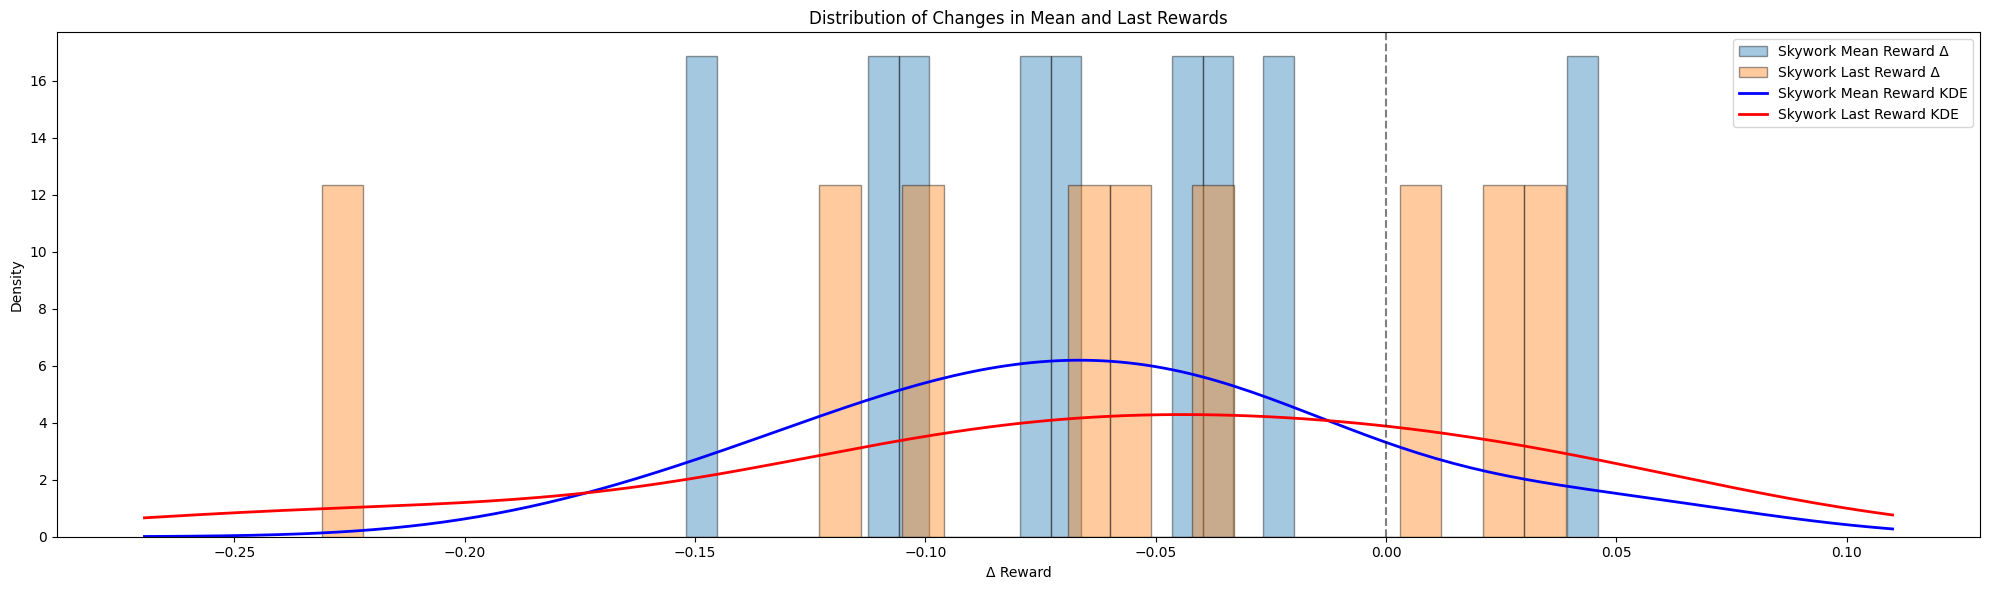

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Calculate mean rewards for original and augmented versions
df_filtered = df_sample[df_sample["equivalence"] == True]
print(f"Number of equivalent samples: {len(df_filtered)} out of {len(df_sample)}")
# Filter out rows where aug_steps is empty
# Filter out rows where number of steps don't match between original and augmented
df_filtered = df_filtered[df_filtered.apply(lambda row: len(row["aug_steps"]) == len(row["steps"]), axis=1)]
df_filtered = df_filtered[df_filtered["aug_steps"].apply(lambda x: len(x) > 0)]
df_filtered = df_filtered[df_filtered["steps"].apply(lambda x: len(x) > 0)]

# df_filtered = df_filtered[df_filtered["generator"].str.contains("Llama-3.1-8B-Instruct", case=False)]
# Filter for correct final answers
# df_filtered = df_filtered[df_filtered["final_answer_correct"] == True]
# df_filtered = df_filtered[df_filtered["split"] == "olympiadbench"]

print(f"Number of filtered samples: {len(df_filtered)} out of {len(df_sample)}")

# Calculate mean rewards for Skywork model
original_rewards_mean_skywork = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].apply(lambda x: np.mean(x))
augmented_rewards_mean_skywork = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"].apply(lambda x: np.mean(x))

# Calculate last rewards for Skywork model
original_rewards_last_skywork = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].apply(lambda x: x[-1])
augmented_rewards_last_skywork = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"].apply(lambda x: x[-1])

# Calculate mean rewards for Qwen model
original_rewards_mean_qwen = df_filtered["Qwen2.5-Math-PRM-7B"].apply(lambda x: np.mean(x))
augmented_rewards_mean_qwen = df_filtered["Qwen/Qwen2.5-Math-PRM-7B--aug_rewards"].apply(lambda x: np.mean(x))

# Calculate last rewards for Qwen model
original_rewards_last_qwen = df_filtered["Qwen2.5-Math-PRM-7B"].apply(lambda x: x[-1])
augmented_rewards_last_qwen = df_filtered["Qwen/Qwen2.5-Math-PRM-7B--aug_rewards"].apply(lambda x: x[-1])

# Calculate deltas
mean_reward_deltas_skywork = augmented_rewards_mean_skywork - original_rewards_mean_skywork
last_reward_deltas_skywork = augmented_rewards_last_skywork - original_rewards_last_skywork
mean_reward_deltas_qwen = augmented_rewards_mean_qwen - original_rewards_mean_qwen
last_reward_deltas_qwen = augmented_rewards_last_qwen - original_rewards_last_qwen

# Create single plot
plt.figure(figsize=(20, 6))

# Plot distributions for Skywork
plt.hist(mean_reward_deltas_skywork, bins=30, density=True, alpha=0.4, edgecolor='black', label='Skywork Mean Reward Δ')
plt.hist(last_reward_deltas_skywork, bins=30, density=True, alpha=0.4, edgecolor='black', label='Skywork Last Reward Δ')

# Plot distributions for Qwen
# plt.hist(mean_reward_deltas_qwen, bins=30, density=True, alpha=0.4, edgecolor='red', label='Qwen Mean Reward Δ')
# plt.hist(last_reward_deltas_qwen, bins=30, density=True, alpha=0.4, edgecolor='red', label='Qwen Last Reward Δ')

# Add KDE curves
kde1 = stats.gaussian_kde(mean_reward_deltas_skywork)
kde2 = stats.gaussian_kde(last_reward_deltas_skywork)
kde3 = stats.gaussian_kde(mean_reward_deltas_qwen)
kde4 = stats.gaussian_kde(last_reward_deltas_qwen)

x_range = np.linspace(min(mean_reward_deltas_skywork.min(), last_reward_deltas_skywork.min(), 
                         mean_reward_deltas_qwen.min(), last_reward_deltas_qwen.min()),
                      max(mean_reward_deltas_skywork.max(), last_reward_deltas_skywork.max(),
                          mean_reward_deltas_qwen.max(), last_reward_deltas_qwen.max()), 200)

plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='Skywork Mean Reward KDE')
plt.plot(x_range, kde2(x_range), 'r-', lw=2, label='Skywork Last Reward KDE')
# plt.plot(x_range, kde3(x_range), 'g-', lw=2, label='Qwen Mean Reward KDE')
# plt.plot(x_range, kde4(x_range), 'y-', lw=2, label='Qwen Last Reward KDE')

plt.title('Distribution of Changes in Mean and Last Rewards')
plt.xlabel('Δ Reward')
plt.ylabel('Density')
plt.legend()
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)

# Add statistics text box
# plt.text(0.02, 0.95,
#          f'Skywork Mean Reward Δ:\n  Mean: {mean_reward_deltas_skywork.mean():.3f}\n  Median: {mean_reward_deltas_skywork.median():.3f}\n  Std: {mean_reward_deltas_skywork.std():.3f}\n\n'
#          f'Skywork Last Reward Δ:\n  Mean: {last_reward_deltas_skywork.mean():.3f}\n  Median: {last_reward_deltas_skywork.median():.3f}\n  Std: {last_reward_deltas_skywork.std():.3f}\n\n'
#          f'Qwen Mean Reward Δ:\n  Mean: {mean_reward_deltas_qwen.mean():.3f}\n  Median: {mean_reward_deltas_qwen.median():.3f}\n  Std: {mean_reward_deltas_qwen.std():.3f}\n\n'
#          f'Qwen Last Reward Δ:\n  Mean: {last_reward_deltas_qwen.mean():.3f}\n  Median: {last_reward_deltas_qwen.median():.3f}\n  Std: {last_reward_deltas_qwen.std():.3f}',
#          transform=plt.gca().transAxes,
#          bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [20]:
df_filtered['last_reward_deltas_skywork'] = last_reward_deltas_skywork
df_filtered['mean_reward_deltas_skywork'] = mean_reward_deltas_skywork

In [21]:
df_filtered.sort_values(by='mean_reward_deltas_skywork', ascending=True, inplace=True)
df_filtered.head(100)

,id,generator,problem,steps,final_answer_correct,label,split,steps_len,per_step_len,Qwen2.5-Math-PRM-7B,Skywork-o1-Open-PRM-Qwen-2.5-7B,aug_problem,aug_steps,equivalence,body_equivalence_results,Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards,Qwen/Qwen2.5-Math-PRM-7B--aug_rewards,last_reward_deltas_skywork,mean_reward_deltas_skywork
4,math-79,Qwen2.5-Math-72B-Instruct,Let $f(z)= \frac{z+a}{z+b}$ and $g(z)=f(f(z))$...,"[To solve the problem, we start by analyzing t...",False,3,math,11,"[241, 310, 531, 128, 84, 227, 115, 234, 127, 7...","[0.796875, 0.98046875, 0.7109375, 0.14453125, ...","[0.22678363486528472, 0.3225259830643727, 0.29...",Let \( f(z)= \frac{z+a}{z+b} \) and \( g(z)=f(...,"[Since \( g(g(z)) = z \), \( g(z) \) is an inv...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.10230470789265304, 0.11596071825396675, 0.1...","[0.97265625, 0.87109375, 0.1611328125, 0.03710...",0.003278,-0.151933
5,olympiadbench-473,Qwen2.5-Math-7B-Instruct,"A bag contains 3 green balls, 4 red balls, and...",[To determine the probability that Victor stop...,False,1,olympiadbench,10,"[319, 200, 427, 356, 534, 539, 85, 123, 223, 138]","[0.99609375, 0.51953125, 0.9453125, 1.0, 0.996...","[0.09009299396195182, 0.09534946489910949, 0.2...","A bag contains 3 green balls, 4 red balls, and...",[To determine the probability that Victor stop...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.06371499425196533, 0.044680870272650205, 0....","[0.9765625, 0.84375, 0.96875, 1.0, 0.99609375,...",-0.066045,-0.110654
1,math-355,Qwen2.5-Math-72B-Instruct,There is a unique polynomial $P(x)$ of degree ...,[To find the polynomial \( P(x) \) of degree 8...,False,4,math,6,"[410, 504, 255, 197, 380, 50]","[0.95703125, 0.953125, 0.97265625, 1.0, 0.0247...","[0.23091976292927177, 0.17667160102063315, 0.1...",There is a unique polynomial \( P(x) \) of deg...,"[To find \( P(x) \), the degree 8 polynomial w...",True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.2337063569140403, 0.2173375210470625, 0.121...","[0.94921875, 0.9609375, 0.984375, 0.99609375, ...",-0.231048,-0.101274
8,omnimath-381,Qwen2.5-Math-72B-Instruct,Consider an equilateral triangular grid $G$ wi...,[To determine the sum of all possible values o...,False,3,omnimath,8,"[252, 291, 164, 332, 113, 126, 111, 186]","[0.984375, 0.98046875, 0.984375, 0.984375, 0.9...","[0.06853749303199023, 0.10521053670308636, 0.1...",Consider an equilateral triangular grid \( G \...,[To find the sum of all possible areas of the ...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.042722197546490565, 0.049589022984031735, 0...","[0.9921875, 0.96875, 0.98828125, 0.95703125, 0...",-0.121829,-0.076806
7,olympiadbench-771,Qwen2.5-7B-Instruct,In the series of odd numbers $1+3+5-7-9-11+13+...,[To find the sum of the first 300 terms of the...,True,1,olympiadbench,7,"[275, 453, 213, 97, 132, 107, 71]","[0.82421875, 0.2197265625, 0.86328125, 0.99218...","[0.14608724704829568, 0.16885695214168317, 0.3...",In the series of odd numbers \(1+3+5-7-9-11+13...,[To find the sum of the first 300 terms of the...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.08151975597471893, 0.08632347658627028, 0.3...","[0.8828125, 0.306640625, 0.9609375, 0.98046875...",0.028411,-0.070132
2,olympiadbench-696,Qwen2-7B-Instruct,"In ARMLopolis, every house number is a positiv...",[To determine which house(s) with a positive n...,True,1,olympiadbench,7,"[405, 330, 319, 137, 422, 115, 388]","[0.9609375, 0.70703125, 0.77734375, 0.98046875...","[0.23091976292927177, 0.21337717541660495, 0.4...",Of the houses with positive numbers less than ...,[To find the house(s) with positive numbers le...,True,\n <step_count>Y</step_count>\n <question>Y<...,"[0.2030746281894702, 0.23091976292927177, 0.43...","[0.984375, 0.96484375, 0.97265625, 0.98828125,...",-0.098665,-0.043224
6,math-101,Meta-Llama-3-70B-Instruct,"Let $r, s,$ and $t$ be solutions to the equati...","[Since $r, s,$ and $t$ are the roots of the cu...",False,3,math

In [28]:
df_filtered['body_equivalence_results'].values[0]

'\n  <step_count>Y</step_count>\n  <question>Y</question>\n  <step1>Y</step1>\n  <step2>Y</step2>\n  <step3>Y</step3>\n  <step4>Y</step4>\n  <step5>Y</step5>\n  <step6>Y</step6>\n  <step7>Y</step7>\n  <step8>Y</step8>\n  <step9>Y</step9>\n  <step10>Y</step10>\n  <step11>Y</step11>\n  <step12>Y</step12>\n'

Number of equivalent samples: 2588 out of 3400


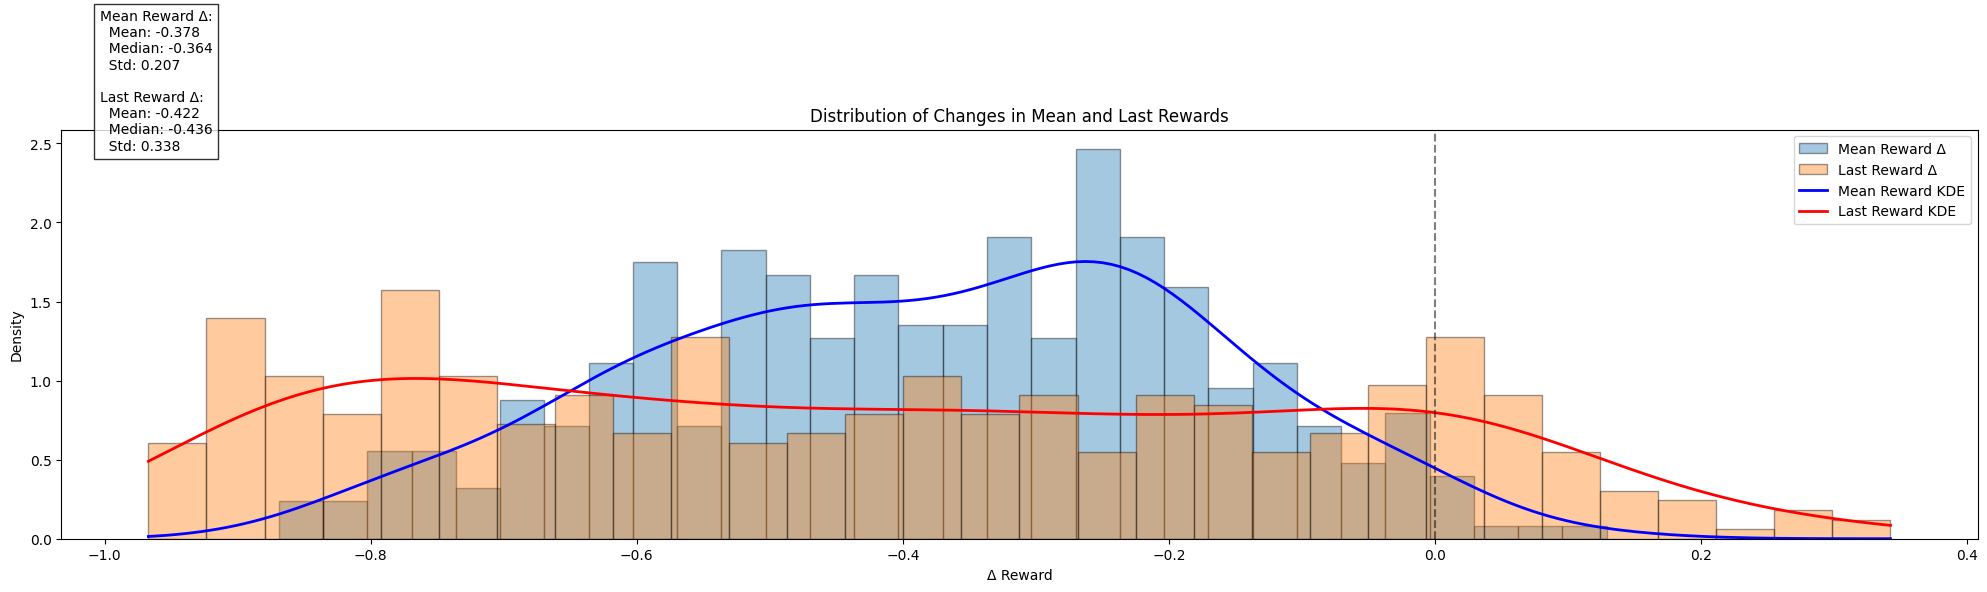

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Calculate mean rewards for original and augmented versions
df_filtered = df_sample[df_sample["equivalence"] == True]
print(f"Number of equivalent samples: {len(df_filtered)} out of {len(df_sample)}")
# Filter out rows where aug_steps is empty
df_filtered = df_filtered[df_filtered["aug_steps"].apply(lambda x: len(x) > 0)]
# df_filtered = df_filtered[df_filtered["generator"].str.contains("qwen", case=False)]
# Filter for correct final answers
df_filtered = df_filtered[df_filtered["final_answer_correct"] == True]

df_filtered = df_filtered[df_filtered["split"] == "olympiadbench"]



# Calculate mean rewards
original_rewards_mean = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].apply(lambda x: np.mean(x))
augmented_rewards_mean = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--rewards"].apply(lambda x: np.mean(x))

# Calculate last rewards
original_rewards_last = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].apply(lambda x: x[-1])
augmented_rewards_last = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--rewards"].apply(lambda x: x[-1])

# Calculate deltas
mean_reward_deltas = augmented_rewards_mean - original_rewards_mean
last_reward_deltas = augmented_rewards_last - original_rewards_last

# Create single plot
plt.figure(figsize=(20, 6))

# Plot both distributions
plt.hist(mean_reward_deltas, bins=30, density=True, alpha=0.4, edgecolor='black', label='Mean Reward Δ')
plt.hist(last_reward_deltas, bins=30, density=True, alpha=0.4, edgecolor='black', label='Last Reward Δ')

# Add KDE curves
kde1 = stats.gaussian_kde(mean_reward_deltas)
kde2 = stats.gaussian_kde(last_reward_deltas)
x_range = np.linspace(min(mean_reward_deltas.min(), last_reward_deltas.min()), 
                      max(mean_reward_deltas.max(), last_reward_deltas.max()), 200)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='Mean Reward KDE')
plt.plot(x_range, kde2(x_range), 'r-', lw=2, label='Last Reward KDE')

plt.title('Distribution of Changes in Mean and Last Rewards')
plt.xlabel('Δ Reward')
plt.ylabel('Density')
plt.legend()
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)

# Add statistics text box
plt.text(0.02, 0.95,
         f'Mean Reward Δ:\n  Mean: {mean_reward_deltas.mean():.3f}\n  Median: {mean_reward_deltas.median():.3f}\n  Std: {mean_reward_deltas.std():.3f}\n\n'
         f'Last Reward Δ:\n  Mean: {last_reward_deltas.mean():.3f}\n  Median: {last_reward_deltas.median():.3f}\n  Std: {last_reward_deltas.std():.3f}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [72]:
augmented_rewards.values

array([0.08565747, 0.28452963, 0.16763784, ..., 0.10902163, 0.1946282 ,
       0.23784341])

In [55]:
df_filtered.loc[2165]

id                                                                                  olympiadbench-765
generator                                                                   Qwen2.5-Math-72B-Instruct
problem                                             Compute the sum of all values of $k$ for which...
steps                                               [To solve the given system of equations, we st...
final_answer_correct                                                                             True
label                                                                                               5
split                                                                                   olympiadbench
steps_len                                                                                           7
per_step_len                                                      [630, 456, 358, 537, 814, 472, 203]
Qwen2.5-Math-PRM-7B                                 [0.98046875, 1.0, 0.97265625, 

In [49]:
df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--rewards"].apply(lambda x: np.mean(x))[2165]

/home/rishabhtiwari/anaconda3/envs/reasoning2/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/rishabhtiwari/anaconda3/envs/reasoning2/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan